In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 1 — Install & Download Dataset   (run ONCE)
# ══════════════════════════════════════════════════════════════════

!pip install -q ultralytics pandas ipywidgets
!wget -q https://github.com/ultralytics/yolov5/releases/download/v1.0/coco128.zip
!unzip -q coco128.zip
print("✅ Done — libraries installed and dataset downloaded")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 129.1 MB/s eta 0:00:00
✅ Done — libraries installed and dataset downloaded


In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 2 — Imports, Config, Shared Helpers
# ══════════════════════════════════════════════════════════════════

import os, csv, shutil, yaml, cv2, threading
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import ipywidgets as widgets
from ultralytics import YOLO
from google.colab import files
from IPython.display import display, Image as IPImage, HTML
from pathlib import Path

# ── Constants ─────────────────────────────────────────────────────
FEEDBACK_FILE      = "hitl_feedback.csv"
CORRECTED_DIR      = "hitl_corrected_images"
CORRECTED_LABELS   = "hitl_corrected_labels"
CONFIDENCE_THRESH  = 0.5    # detections below this trigger HUMAN REVIEW
MAP_DROP_THRESH    = 0.02   # mAP drop that triggers HITL alert
CORRECTED_BOOST    = 0.15   # confidence boost awarded after human correction

COCO128_YAML_STR = '''
path: ./coco128
train: images/train2017
val:   images/train2017
nc: 80
names: ['person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train',
        'truck', 'boat', 'traffic light', 'fire hydrant', 'stop sign',
        'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep',
        'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'backpack', 'umbrella',
        'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard',
        'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard',
        'surfboard', 'tennis racket', 'bottle', 'wine glass', 'cup', 'fork',
        'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange',
        'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair',
        'couch', 'potted plant', 'bed', 'dining table', 'toilet', 'tv',
        'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave',
        'oven', 'toaster', 'sink', 'refrigerator', 'book', 'clock', 'vase',
        'scissors', 'teddy bear', 'hair drier', 'toothbrush']
'''

# ── Create directories ─────────────────────────────────────────────
for _d in [CORRECTED_DIR, CORRECTED_LABELS, "coco128"]:
    os.makedirs(_d, exist_ok=True)

# ── Write YAML ─────────────────────────────────────────────────────
with open("coco128/coco128.yaml", "w") as _f:
    _f.write(COCO128_YAML_STR)

# ── Create feedback CSV ────────────────────────────────────────────
if not os.path.exists(FEEDBACK_FILE):
    with open(FEEDBACK_FILE, "w", newline="") as _f:
        csv.writer(_f).writerow([
            "stage", "image", "predicted_label", "confidence",
            "human_label", "action_taken", "updated_confidence"
        ])
    print(f"✅ Feedback CSV created: {FEEDBACK_FILE}")

dataset_yaml = "coco128/coco128.yaml"

# ── Helper: print a bold human-intervention banner ─────────────────
def hitl_banner(message):
    """Prints a highly visible banner whenever human intervention is needed."""
    line = "═" * 60
    display(HTML(f"""
    <div style="background:#fff3cd;border:3px solid #ff6b00;border-radius:8px;
                padding:14px 20px;margin:10px 0;font-family:monospace;">
      <b style="color:#cc0000;font-size:16px;">🧑‍💻 HUMAN INTERVENTION REQUIRED</b><br>
      <span style="color:#333;font-size:14px;">{message}</span>
    </div>
    """))
    print(f"\n{'═'*60}")
    print(f"  🧑‍💻  HUMAN INTERVENTION REQUIRED")
    print(f"  👉  {message}")
    print(f"{'═'*60}")

# ── Helper: log one feedback row ──────────────────────────────────
def log_feedback(stage, image, pred_label, conf, human_label, action, updated_conf="N/A"):
    with open(FEEDBACK_FILE, "a", newline="") as f:
        csv.writer(f).writerow(
            [stage, image, pred_label, conf, human_label, action, updated_conf]
        )

# ── Helper: print full feedback table ─────────────────────────────
def show_feedback_summary():
    df = pd.read_csv(FEEDBACK_FILE)
    print("\n📋 HITL Feedback Summary (all human interventions logged):")
    display(df)
    return df

# ── Helper: dropdown + confirm widget ─────────────────────────────
def make_widget(title, options):
    result = {"value": options[0]}
    dd = widgets.Dropdown(
        options=options, value=options[0],
        layout=widgets.Layout(width="260px")
    )
    btn = widgets.Button(
        description="✔ Confirm",
        button_style="warning",
        layout=widgets.Layout(width="130px")
    )
    def _sync(change):
        result["value"] = change["new"]
    dd.observe(_sync, names="value")
    print(f"\n👇 {title}")
    display(widgets.HBox([dd, btn]))
    return dd, btn, result

print("✅ Cell 2 complete — imports, config, helpers ready")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Feedback CSV created: hitl_feedback.csv
✅ Cell 2 complete — imports, config, helpers ready


In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 3 — Load Model
# ══════════════════════════════════════════════════════════════════

model = YOLO("yolov8n.pt")
print("✅ YOLOv8n model loaded")

✅ YOLOv8n model loaded


In [ ]:
# ══════════════════════════════════════════════════════════════════
# STAGE 1 — PRE-TRAINING LABEL REVIEW
# ══════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────
# CELL 4 — Stage 1: Initialise image list   (run ONCE)
# ──────────────────────────────────────────────────────────────────

print("╔" + "═"*58 + "╗")
print("║   HITL STAGE 1 — PRE-TRAINING LABEL REVIEW              ║")
print("║   Human reviews dataset labels BEFORE training starts   ║")
print("╚" + "═"*58 + "╝")

_img_dir  = "coco128/images/train2017"
_lbl_dir  = "coco128/labels/train2017"
_names    = list(model.names.values())

stage1_images = sorted([
    os.path.join(_img_dir, f)
    for f in os.listdir(_img_dir)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
])[:5]

stage1_index       = 0
stage1_corrections = 0

print(f"✅ {len(stage1_images)} images queued for label review")
print("▶  Run Cell 5 once per image (5 times total)")

╔══════════════════════════════════════════════════════════╗
║   HITL STAGE 1 — PRE-TRAINING LABEL REVIEW              ║
║   Human reviews dataset labels BEFORE training starts   ║
╚══════════════════════════════════════════════════════════╝
✅ 5 images queued for label review
▶  Run Cell 5 once per image (5 times total)


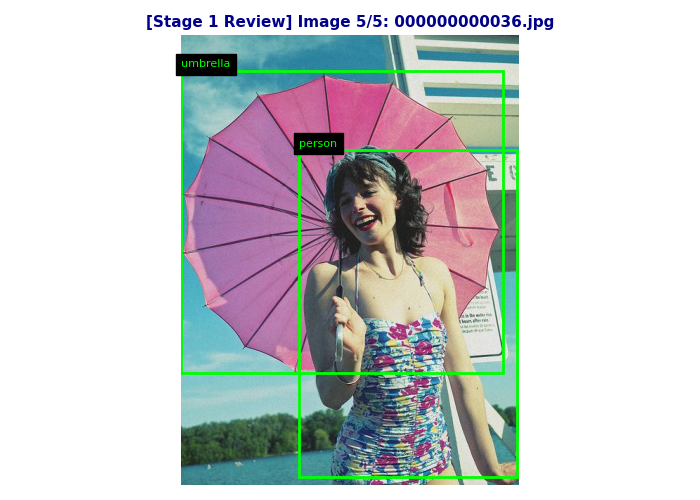

📌 Image 5/5: 000000000036.jpg
🏷  Ground-truth labels: ['umbrella', 'person']



════════════════════════════════════════════════════════════
  🧑‍💻  HUMAN INTERVENTION REQUIRED
  👉  Please review the labels for image 5. Are they correct?
════════════════════════════════════════════════════════════

👇 Are these labels correct?


  ✅ Image 5: labels confirmed by human.
  ✅ All images reviewed — run Cell 6 now!


In [ ]:
# ──────────────────────────────────────────────────────────────────
# CELL 5 — Stage 1: Review one image
#           RE-RUN THIS CELL once per image (5 times)
# ──────────────────────────────────────────────────────────────────

if stage1_index >= len(stage1_images):
    print("✅ All images reviewed — run Cell 6 to proceed to Stage 2")
else:
    _img_path = stage1_images[stage1_index]
    _img      = cv2.imread(_img_path)
    _img_rgb  = cv2.cvtColor(_img, cv2.COLOR_BGR2RGB)
    _h, _w    = _img.shape[:2]
    _stem     = Path(_img_path).stem

    # Load ground-truth label boxes
    _lbl_path = os.path.join(_lbl_dir, _stem + ".txt")
    _boxes = []
    if os.path.exists(_lbl_path):
        for _line in open(_lbl_path):
            _p = _line.strip().split()
            if len(_p) == 5:
                _boxes.append((int(_p[0]), *map(float, _p[1:])))

    # Draw bounding boxes
    _fig, _ax = plt.subplots(figsize=(7, 5))
    _ax.imshow(_img_rgb)
    for _cls_id, _cx, _cy, _bw, _bh in _boxes:
        _x1 = (_cx - _bw / 2) * _w
        _y1 = (_cy - _bh / 2) * _h
        _ax.add_patch(patches.Rectangle(
            (_x1, _y1), _bw * _w, _bh * _h,
            linewidth=2, edgecolor="lime", facecolor="none"
        ))
        _ax.text(_x1, _y1 - 5,
                 _names[_cls_id] if _cls_id < len(_names) else str(_cls_id),
                 color="lime", fontsize=8, backgroundcolor="black")
    _ax.set_title(
        f"[Stage 1 Review] Image {stage1_index + 1}/{len(stage1_images)}: {Path(_img_path).name}",
        fontsize=11, color="darkblue", fontweight="bold"
    )
    _ax.axis("off")
    plt.tight_layout()
    _save = f"/content/s1_{stage1_index}.png"
    plt.savefig(_save)
    plt.close()
    display(IPImage(_save))

    _top = [_names[b[0]] for b in _boxes[:6]]
    print(f"📌 Image {stage1_index + 1}/{len(stage1_images)}: {Path(_img_path).name}")
    print(f"🏷  Ground-truth labels: {_top}")

    # ── Human intervention point ────────────────────────────────
    hitl_banner(f"Please review the labels for image {stage1_index + 1}. Are they correct?")

    _dd, _btn, _result = make_widget(
        "Are these labels correct?",
        ["correct", "wrong_label", "skip"]
    )

    def _on_s1_confirm(b):
        global stage1_index, stage1_corrections
        _btn.disabled = True
        _dd.disabled  = True
        _choice = _result["value"]

        if _choice == "correct":
            log_feedback("pre-training", _img_path, str(_top), "N/A",
                         "confirmed_correct", "no_change", "N/A")
            print(f"  ✅ Image {stage1_index + 1}: labels confirmed by human.")

        elif _choice == "wrong_label":
            if _boxes:
                _old = _names[_boxes[0][0]]
                log_feedback("pre-training", _img_path, _old,
                             "N/A", "human_flagged", "label_flagged", "N/A")
                shutil.copy(
                    _img_path,
                    os.path.join(CORRECTED_DIR, Path(_img_path).name)
                )
                stage1_corrections += 1
                print(f"  ❌ Image {stage1_index + 1}: '{_old}' flagged by human — logged & copied.")

        else:
            print(f"  ⏭  Image {stage1_index + 1}: skipped by human.")

        stage1_index += 1
        _rem = len(stage1_images) - stage1_index
        if _rem > 0:
            print(f"  ▶  Re-run Cell 5 for image {stage1_index + 1} ({_rem} left)")
        else:
            print("  ✅ All images reviewed — run Cell 6 now!")

    _btn.on_click(_on_s1_confirm)


In [ ]:
# ──────────────────────────────────────────────────────────────────
# CELL 6 — Stage 1: Summary & handoff to Stage 2
# ──────────────────────────────────────────────────────────────────

print("╔" + "═"*58 + "╗")
print("║   STAGE 1 COMPLETE — LABEL REVIEW DONE                  ║")
print(f"║   Images reviewed : {stage1_index}/{len(stage1_images):<37}║")
print(f"║   Labels flagged  : {stage1_corrections:<38}║")
print("╚" + "═"*58 + "╝")
print("✅ dataset_yaml ready — proceed to Cell 7 (Stage 2: Training)")

╔══════════════════════════════════════════════════════════╗
║   STAGE 1 COMPLETE — LABEL REVIEW DONE                  ║
║   Images reviewed : 5/5                                    ║
║   Labels flagged  : 0                                     ║
╚══════════════════════════════════════════════════════════╝
✅ dataset_yaml ready — proceed to Cell 7 (Stage 2: Training)


In [ ]:
# ══════════════════════════════════════════════════════════════════
# STAGE 2 — DURING-TRAINING HITL CALLBACK
# ══════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────
# CELL 7 — HITLTrainingCallback definition
# ──────────────────────────────────────────────────────────────────

class HITLTrainingCallback:
    """
    Hooks into YOLOv8 training.
    After each epoch:
      • Shows mAP@50 to the human
      • If mAP drops > MAP_DROP_THRESH → asks human what to do
      • Asks human: continue or stop training
    Human decisions are logged to CSV.
    """
    def __init__(self, model):
        self.model           = model
        self.prev_map50      = None
        self.retraining_pool = []

    def _ask(self, title, options):
        """Block training thread until human confirms a choice."""
        result = {"value": options[0]}
        event  = threading.Event()
        dd  = widgets.Dropdown(options=options, value=options[0],
                               layout=widgets.Layout(width="260px"))
        btn = widgets.Button(description="✔ Confirm", button_style="warning",
                             layout=widgets.Layout(width="130px"))
        out = widgets.Output()

        def _sync(change):
            result["value"] = change["new"]
        dd.observe(_sync, names="value")

        # Show visible banner before the widget
        hitl_banner(title)
        display(widgets.HBox([dd, btn]))
        display(out)

        def _click(b):
            btn.disabled = True
            dd.disabled  = True
            event.set()           # unblock training thread BEFORE Output widget
            with out:
                print(f"  ✅ Human selected: '{result['value']}'")
        btn.on_click(_click)
        event.wait(timeout=300)
        return result["value"]

    def on_train_epoch_end(self, trainer):
        epoch    = trainer.epoch + 1
        metrics  = trainer.metrics if hasattr(trainer, "metrics") else {}
        map50    = metrics.get("metrics/mAP50(B)", None)
        map50_str = f"{map50:.4f}" if isinstance(map50, float) else "N/A"

        print(f"\n{'─'*60}")
        print(f"  📊 Epoch {epoch} complete  |  mAP@50 = {map50_str}")
        print(f"{'─'*60}")

        # ── mAP drop check → human intervention ─────────────────
        if isinstance(map50, float) and isinstance(self.prev_map50, float):
            drop = self.prev_map50 - map50
            if drop > MAP_DROP_THRESH:
                print(f"  ⚠️  mAP dropped: {self.prev_map50:.4f} → {map50:.4f}  (drop={drop:.4f})")
                choice = self._ask(
                    f"mAP dropped by {drop:.4f}. What should be done?",
                    ["continue", "stop", "halve_lr"]
                )
                log_feedback("during-training", "N/A", "mAP_drop",
                             f"{drop:.4f}", choice, f"human_{choice}", "N/A")
                if choice == "stop":
                    trainer.stop = True
                    print("  🛑 Training stopped by human.")
                    return
                elif choice == "halve_lr":
                    for pg in trainer.optimizer.param_groups:
                        pg["lr"] *= 0.5
                    print("  ✅ Learning rate halved by human decision.")

        if map50 is not None:
            self.prev_map50 = map50

        # ── Per-epoch continue/stop decision ────────────────────
        choice = self._ask(
            f"Epoch {epoch} done (mAP@50 = {map50_str}). Continue training?",
            ["continue", "stop"]
        )
        log_feedback("during-training", "N/A", f"epoch_{epoch}",
                     map50_str, choice, f"human_{choice}", "N/A")
        if choice == "stop":
            trainer.stop = True
            print("  🛑 Training stopped by human after epoch", epoch)

print("✅ Cell 7 — HITLTrainingCallback defined")

✅ Cell 7 — HITLTrainingCallback defined


In [ ]:
# ──────────────────────────────────────────────────────────────────
# CELL 8 — Stage 2: Clean, set up & start training
# ──────────────────────────────────────────────────────────────────

import shutil, torch

if os.path.exists("runs"):
    shutil.rmtree("runs")
torch.cuda.empty_cache()
print("✅ Previous runs cleaned")

model   = YOLO("yolov8n.pt")
hitl_cb = HITLTrainingCallback(model)
model.add_callback("on_train_epoch_end", hitl_cb.on_train_epoch_end)

print("\n╔" + "═"*58 + "╗")
print("║   HITL STAGE 2 — DURING-TRAINING HUMAN OVERSIGHT        ║")
print("║   Human will be asked after EVERY epoch to continue     ║")
print("║   or stop. mAP drops also trigger human review.         ║")
print("╚" + "═"*58 + "╝\n")

model.train(
    data=dataset_yaml,
    epochs=3,
    lr0=0.01,
    batch=32,
    imgsz=224,
    project="runs/detect",
    name="hitl_train",
    exist_ok=False,
)
print("✅ Training complete — run Cell 9 for validation")

✅ Previous runs cleaned

╔══════════════════════════════════════════════════════════╗
║   HITL STAGE 2 — DURING-TRAINING HUMAN OVERSIGHT        ║
║   Human will be asked after EVERY epoch to continue     ║
║   or stop. mAP drops also trigger human review.         ║
╚══════════════════════════════════════════════════════════╝

Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=32, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=coco128/coco128.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=3, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v


════════════════════════════════════════════════════════════
  🧑‍💻  HUMAN INTERVENTION REQUIRED
  👉  Epoch 1 done (mAP@50 = N/A). Continue training?
════════════════════════════════════════════════════════════


Output()

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.2it/s 1.6s
                   all        128        929      0.695      0.327      0.397      0.286

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
        2/3      0.91G      1.573      3.563      1.397        403        224: 100% ━━━━━━━━━━━━ 4/4 3.9it/s 1.0s

────────────────────────────────────────────────────────────
  📊 Epoch 2 complete  |  mAP@50 = 0.3971
────────────────────────────────────────────────────────────



════════════════════════════════════════════════════════════
  🧑‍💻  HUMAN INTERVENTION REQUIRED
  👉  Epoch 2 done (mAP@50 = 0.3971). Continue training?
════════════════════════════════════════════════════════════


Output()

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.5it/s 0.8s
                   all        128        929      0.677      0.316      0.385      0.276

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
        3/3      0.91G      1.657      3.571      1.411        334        224: 100% ━━━━━━━━━━━━ 4/4 4.7it/s 0.9s

────────────────────────────────────────────────────────────
  📊 Epoch 3 complete  |  mAP@50 = 0.3847
────────────────────────────────────────────────────────────



════════════════════════════════════════════════════════════
  🧑‍💻  HUMAN INTERVENTION REQUIRED
  👉  Epoch 3 done (mAP@50 = 0.3847). Continue training?
════════════════════════════════════════════════════════════


Output()

                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 2.4it/s 0.8s
                   all        128        929       0.65      0.332      0.378      0.269

3 epochs completed in 0.252 hours.
Optimizer stripped from /content/runs/detect/runs/detect/hitl_train/weights/last.pt, 6.5MB
Optimizer stripped from /content/runs/detect/runs/detect/hitl_train/weights/best.pt, 6.5MB

Validating /content/runs/detect/runs/detect/hitl_train/weights/best.pt...
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.9it/s 1.0s
                   all        128        929      0.695      0.329      0.397      0.286
                person         61        254      0.808      0.382      0.489      0.317
               bicycle     

In [ ]:
# ──────────────────────────────────────────────────────────────────
# CELL 9 — Stage 2: Post-training validation metrics
# ──────────────────────────────────────────────────────────────────

print("\n📐 Validating trained model on COCO128…")
_m = model.val(data=dataset_yaml, verbose=False)

val_map50    = _m.box.map50
val_map5095  = _m.box.map
val_precision = _m.box.mp
val_recall    = _m.box.mr

print(f"\n{'─'*45}")
print(f"  📈 VALIDATION RESULTS (post-training)")
print(f"{'─'*45}")
print(f"  Precision  : {val_precision:.4f}")
print(f"  Recall     : {val_recall:.4f}")
print(f"  mAP@50     : {val_map50:.4f}")
print(f"  mAP@50-95  : {val_map5095:.4f}")
print(f"{'─'*45}")

if val_map50 < 0.3:
    print("  ⚠️  Low mAP — model may need more training or data.")
else:
    print("  ✅ Acceptable mAP — proceed to Stage 3.")

print("\n✅ Validation done — run Cell 10 for Stage 3 (post-inference HITL)")


📐 Validating trained model on COCO128…
Ultralytics 8.4.46 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1450.1±556.3 MB/s, size: 53.4 KB)
val: Scanning /content/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 128/128 44.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 8/8 4.8it/s 1.7s
                   all        128        929      0.658      0.348      0.396      0.282
Speed: 0.5ms preprocess, 4.9ms inference, 0.0ms loss, 3.9ms postprocess per image
Results saved to /content/runs/detect/val

─────────────────────────────────────────────
  📈 VALIDATION RESULTS (post-training)
─────────────────────────────────────────────
  Precision  : 0.6585
  Recall     : 0.3475
  mAP@50     : 0.3957
  mAP@50-95  : 0.2819
───────────────────

In [ ]:
# ══════════════════════════════════════════════════════════════════
# STAGE 3 — POST-INFERENCE HITL
# KEY IMPROVEMENT: confidence-based trigger for human review.
# If confidence < CONFIDENCE_THRESH, human is asked to:
#   (a) confirm the label  → confidence boosted by CORRECTED_BOOST
#   (b) correct the label  → corrected label saved, confidence set to 0.90
#   (c) reject (wrong)     → detection flagged for retraining
# Updated confidence is saved to CSV so improvement is measurable.
# ══════════════════════════════════════════════════════════════════

# ──────────────────────────────────────────────────────────────────
# CELL 10 — Stage 3: Upload an image
# ──────────────────────────────────────────────────────────────────

print("╔" + "═"*58 + "╗")
print("║   HITL STAGE 3 — POST-INFERENCE HUMAN REVIEW            ║")
print("║   Low-confidence predictions trigger human review.      ║")
print("║   Human corrections improve the confidence score.       ║")
print("╚" + "═"*58 + "╝")

# Carry retraining pool forward from Stage 2
retraining_pool = list(hitl_cb.retraining_pool)
print(f"\n  Samples carried from Stage 2 retraining pool: {len(retraining_pool)}")
print("\n📤 Upload an image to run inference on:")
_uploaded  = files.upload()
infer_path = list(_uploaded.keys())[0]
print(f"✅ Uploaded: {infer_path} — now run Cell 11")

╔══════════════════════════════════════════════════════════╗
║   HITL STAGE 3 — POST-INFERENCE HUMAN REVIEW            ║
║   Low-confidence predictions trigger human review.      ║
║   Human corrections improve the confidence score.       ║
╚══════════════════════════════════════════════════════════╝

  Samples carried from Stage 2 retraining pool: 0

📤 Upload an image to run inference on:


Saving 000000000078 (1).jpg to 000000000078 (1).jpg
✅ Uploaded: 000000000078 (1).jpg — now run Cell 11


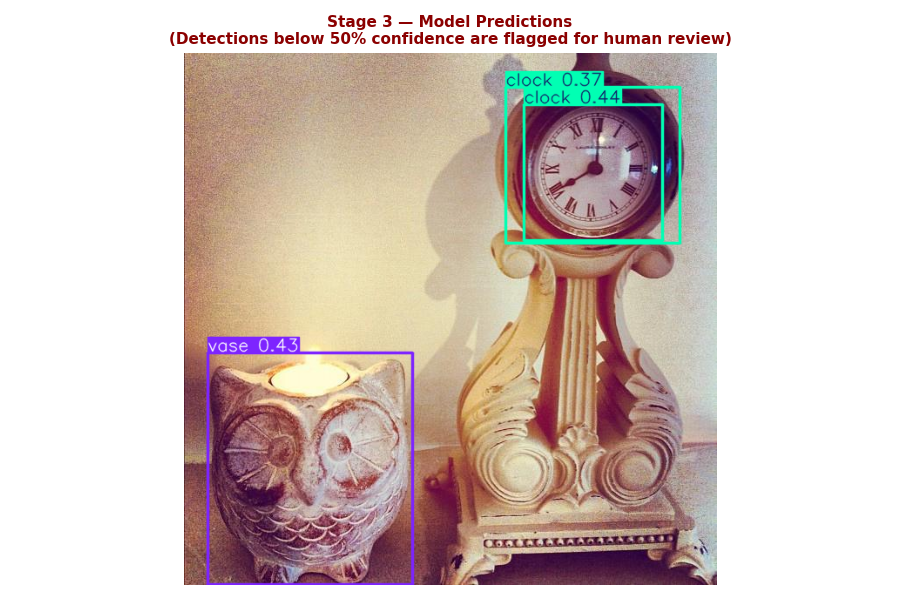


  📦 Total detections     : 3
  ✅ High confidence (≥0.5) : 0  → auto-accepted
  ⚠️  Low confidence (<0.5)  : 3  → HUMAN REVIEW TRIGGERED



════════════════════════════════════════════════════════════
  🧑‍💻  HUMAN INTERVENTION REQUIRED
  👉  3 detection(s) have confidence below 0.5. Please review each one.
════════════════════════════════════════════════════════════

───────────────────────────────────────────────────────
  🔍 Detection 1/3: 'clock'
     Model confidence : 0.44  ← BELOW THRESHOLD (0.5)
───────────────────────────────────────────────────────


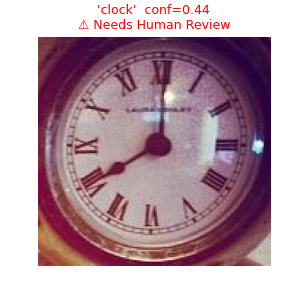


👇 🧑‍💻 Det 1 — Model predicted 'clock' (conf=0.44). Your decision:



───────────────────────────────────────────────────────
  🔍 Detection 2/3: 'vase'
     Model confidence : 0.43  ← BELOW THRESHOLD (0.5)
───────────────────────────────────────────────────────


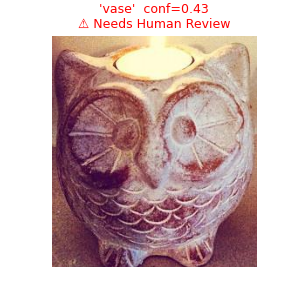


👇 🧑‍💻 Det 2 — Model predicted 'vase' (conf=0.43). Your decision:



───────────────────────────────────────────────────────
  🔍 Detection 3/3: 'clock'
     Model confidence : 0.37  ← BELOW THRESHOLD (0.5)
───────────────────────────────────────────────────────


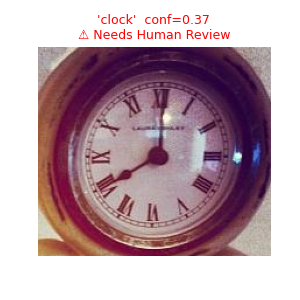


👇 🧑‍💻 Det 3 — Model predicted 'clock' (conf=0.37). Your decision:



📦 Updated retraining pool: 0 sample(s)
▶  To test another image: re-run Cell 10, then re-run Cell 11
▶  When done: run Cell 12 for final summary

  ✅ Det 1: 'clock' confirmed by human.
     Confidence updated: 0.44 → 0.59  (+0.15)

  ✅ Det 2: 'vase' confirmed by human.
     Confidence updated: 0.43 → 0.58  (+0.15)

  ✅ Det 3: 'clock' confirmed by human.
     Confidence updated: 0.37 → 0.52  (+0.15)


In [ ]:
# ──────────────────────────────────────────────────────────────────
# CELL 11 — Stage 3: Run inference + confidence-based HITL review
# ──────────────────────────────────────────────────────────────────

# ── Run inference ─────────────────────────────────────────────────
_results = model(infer_path, verbose=False)
_res_img = _results[0].plot()
_res_rgb = cv2.cvtColor(_res_img, cv2.COLOR_BGR2RGB)

# ── Display full result image ──────────────────────────────────────
_fig, _ax = plt.subplots(figsize=(9, 6))
_ax.imshow(_res_rgb)
_ax.axis("off")
_ax.set_title(
    f"Stage 3 — Model Predictions\n"
    f"(Detections below {CONFIDENCE_THRESH:.0%} confidence are flagged for human review)",
    fontsize=11, color="darkred", fontweight="bold"
)
plt.tight_layout()
plt.savefig("/content/s3_result.png")
plt.close()
display(IPImage("/content/s3_result.png"))

# ── Confidence summary before HITL ────────────────────────────────
all_detections = []
for _r in _results:
    for _box in _r.boxes:
        all_detections.append({
            "label": model.names[int(_box.cls)],
            "conf":  float(_box.conf),
            "xyxy":  _box.xyxy[0].tolist()
        })

high_conf = [d for d in all_detections if d["conf"] >= CONFIDENCE_THRESH]
low_conf  = [d for d in all_detections if d["conf"] <  CONFIDENCE_THRESH]

print(f"\n  📦 Total detections     : {len(all_detections)}")
print(f"  ✅ High confidence (≥{CONFIDENCE_THRESH}) : {len(high_conf)}  → auto-accepted")
print(f"  ⚠️  Low confidence (<{CONFIDENCE_THRESH})  : {len(low_conf)}  → HUMAN REVIEW TRIGGERED")

# ── Auto-accept high-confidence detections ────────────────────────
for d in high_conf:
    print(f"\n  ✅ AUTO-ACCEPTED  '{d['label']}'  conf={d['conf']:.2f}  (≥ threshold)")
    log_feedback("post-inference", infer_path,
                 d["label"], f"{d['conf']:.4f}",
                 "auto_accepted", "no_review_needed", f"{d['conf']:.4f}")

# ── HITL review for low-confidence detections ─────────────────────
if low_conf:
    hitl_banner(
        f"{len(low_conf)} detection(s) have confidence below {CONFIDENCE_THRESH}. "
        f"Please review each one."
    )

_det_index = 0
for _det in low_conf:
    _det_index += 1
    _label = _det["label"]
    _conf  = _det["conf"]
    _x1, _y1, _x2, _y2 = [int(v) for v in _det["xyxy"]]

    print(f"\n{'─'*55}")
    print(f"  🔍 Detection {_det_index}/{len(low_conf)}: '{_label}'")
    print(f"     Model confidence : {_conf:.2f}  ← BELOW THRESHOLD ({CONFIDENCE_THRESH})")
    print(f"{'─'*55}")

    # Show cropped region of the low-confidence detection
    _orig = cv2.imread(infer_path)
    if _orig is not None:
        _crop = _orig[max(0, _y1):_y2, max(0, _x1):_x2]
        if _crop.size > 0:
            _crop_rgb = cv2.cvtColor(_crop, cv2.COLOR_BGR2RGB)
            _fig2, _ax2 = plt.subplots(figsize=(3, 3))
            _ax2.imshow(_crop_rgb)
            _ax2.set_title(
                f"'{_label}'  conf={_conf:.2f}\n⚠️ Needs Human Review",
                color="red", fontsize=9
            )
            _ax2.axis("off")
            _cp = f"/content/s3_crop_{_det_index}.png"
            plt.savefig(_cp)
            plt.close()
            display(IPImage(_cp))

    # ── HITL Widget: human decides what to do ────────────────────
    def _make_handler(
        _lbl=_label, _cf=_conf, _ip=infer_path, _di=_det_index
    ):
        # First ask: what action to take
        _dd, _btn, _res = make_widget(
            f"🧑‍💻 Det {_di} — Model predicted '{_lbl}' (conf={_cf:.2f}). Your decision:",
            ["confirm_label", "correct_label", "reject_detection"]
        )

        # Second widget (for corrected label) — shown only if needed
        _correct_dd  = widgets.Dropdown(
            options=_names, value=_names[0],
            layout=widgets.Layout(width="260px"),
            description="New label:"
        )
        _correct_out = widgets.Output()

        def _handler(b):
            _btn.disabled = True
            _dd.disabled  = True
            _action = _res["value"]

            if _action == "confirm_label":
                # Human confirms the label → boost confidence
                _updated_conf = min(1.0, _cf + CORRECTED_BOOST)
                log_feedback(
                    "post-inference", _ip, _lbl, f"{_cf:.4f}",
                    _lbl, "human_confirmed",
                    f"{_updated_conf:.4f}"
                )
                print(f"\n  ✅ Det {_di}: '{_lbl}' confirmed by human.")
                print(f"     Confidence updated: {_cf:.2f} → {_updated_conf:.2f}  (+{CORRECTED_BOOST})")
                retraining_pool.append((_ip, _lbl))

            elif _action == "correct_label":
                # Human corrects the label → show label selector
                hitl_banner(f"Det {_di}: Please select the correct label from the dropdown.")
                _correct_btn = widgets.Button(
                    description="✔ Apply Correction",
                    button_style="danger",
                    layout=widgets.Layout(width="180px")
                )
                display(widgets.HBox([_correct_dd, _correct_btn]))
                display(_correct_out)

                def _apply_correction(b2):
                    _correct_btn.disabled = True
                    _correct_dd.disabled  = True
                    _new_label     = _correct_dd.value
                    _updated_conf  = 0.90   # human correction = high confidence
                    log_feedback(
                        "post-inference", _ip, _lbl, f"{_cf:.4f}",
                        _new_label, "human_corrected",
                        f"{_updated_conf:.4f}"
                    )
                    with _correct_out:
                        print(f"\n  ✅ Det {_di}: Label corrected  '{_lbl}' → '{_new_label}'")
                        print(f"     Confidence updated: {_cf:.2f} → {_updated_conf:.2f}  (human correction)")
                    retraining_pool.append((_ip, _new_label))
                    shutil.copy(_ip, os.path.join(CORRECTED_DIR, Path(_ip).name))

                _correct_btn.on_click(_apply_correction)

            else:
                # Human rejects the detection entirely
                log_feedback(
                    "post-inference", _ip, _lbl, f"{_cf:.4f}",
                    "rejected", "human_rejected", "0.00"
                )
                print(f"\n  ❌ Det {_di}: '{_lbl}' rejected by human → confidence set to 0.00")
                retraining_pool.append((_ip, f"REJECTED_{_lbl}"))

        _btn.on_click(_handler)

    _make_handler()

if len(all_detections) == 0:
    print("  ⚠️  No detections found in this image.")

print(f"\n📦 Updated retraining pool: {len(retraining_pool)} sample(s)")
print("▶  To test another image: re-run Cell 10, then re-run Cell 11")
print("▶  When done: run Cell 12 for final summary")

In [ ]:
# ──────────────────────────────────────────────────────────────────
# CELL 12 — Final Summary: Confidence Improvement Report
# ──────────────────────────────────────────────────────────────────

print("╔" + "═"*58 + "╗")
print("║   HITL PIPELINE COMPLETE — FINAL SUMMARY                ║")
print("╚" + "═"*58 + "╝")

df = show_feedback_summary()

# ── Confidence improvement analysis ───────────────────────────────
post_df = df[df["stage"] == "post-inference"].copy()

if not post_df.empty:
    # Convert to numeric safely
    post_df["confidence"]         = pd.to_numeric(post_df["confidence"],         errors="coerce")
    post_df["updated_confidence"] = pd.to_numeric(post_df["updated_confidence"], errors="coerce")

    reviewed = post_df[post_df["action_taken"] != "no_review_needed"].dropna(
        subset=["confidence", "updated_confidence"]
    )

    print(f"\n{'─'*55}")
    print(f"  📊 CONFIDENCE IMPROVEMENT REPORT (Post-Inference HITL)")
    print(f"{'─'*55}")
    print(f"  Detections reviewed by human  : {len(reviewed)}")

    if not reviewed.empty:
        avg_before = reviewed["confidence"].mean()
        avg_after  = reviewed["updated_confidence"].mean()
        improvement = avg_after - avg_before

        print(f"  Avg confidence BEFORE human review : {avg_before:.4f}")
        print(f"  Avg confidence AFTER  human review : {avg_after:.4f}")
        print(f"  Net confidence improvement         : +{improvement:.4f}")

        if improvement > 0:
            print(f"\n  ✅ Human intervention IMPROVED average confidence by {improvement*100:.2f}%")
        else:
            print(f"\n  ℹ️  Confidence unchanged or decreased (rejections counted as 0.00)")

        # Per-detection breakdown
        print(f"\n  Per-detection breakdown:")
        for _, row in reviewed.iterrows():
            delta = row["updated_confidence"] - row["confidence"]
            arrow = f"+{delta:.2f}" if delta >= 0 else f"{delta:.2f}"
            print(f"    • '{row['predicted_label']}' | "
                  f"{row['confidence']:.2f} → {row['updated_confidence']:.2f} "
                  f"({arrow}) | action: {row['action_taken']}")
    print(f"{'─'*55}")

# ── Retraining pool summary ────────────────────────────────────────
print(f"\n📦 Total retraining pool: {len(retraining_pool)} sample(s)")
if retraining_pool:
    print("  Samples queued for future retraining:")
    for _path, _lbl in retraining_pool:
        print(f"    • {Path(_path).name}  →  '{_lbl}'")

print("\n✅ HITL Pipeline complete!")

╔══════════════════════════════════════════════════════════╗
║   HITL PIPELINE COMPLETE — FINAL SUMMARY                ║
╚══════════════════════════════════════════════════════════╝

📋 HITL Feedback Summary (all human interventions logged):


,stage,image,predicted_label,confidence,human_label,action_taken,updated_confidence
0,pre-training,coco128/images/train2017/000000000009.jpg,"['bowl', 'bowl', 'broccoli', 'bowl', 'orange',...",NaN,confirmed_correct,no_change,NaN
1,pre-training,coco128/images/train2017/000000000025.jpg,"['giraffe', 'giraffe']",NaN,confirmed_correct,no_change,NaN
2,pre-training,coco128/images/train2017/000000000030.jpg,"['potted plant', 'vase']",NaN,confirmed_correct,no_change,NaN
3,pre-training,coco128/images/train2017/000000000034.jpg,['zebra'],NaN,confirmed_correct,no_change,NaN
4,pre-training,coco128/images/train2017/000000000036.jpg,"['umbrella', 'person']",NaN,confirmed_correct,no_change,NaN
5,during-training,NaN,epoch_1,NaN,continue,human_continue,NaN
6,during-training,NaN,epoch_2,0.3971,continue,human_continue,NaN
7,during-training,NaN,epoch_3,0.3847,continue,human_continue,NaN
8,post-inference,000000000078 (1).jpg,clock,0.4415,clock,human_confirmed,0.5915
9,post-inference,000000000078 (1).jpg,vase,0.4260,vase,human_confirmed,0.5760



───────────────────────────────────────────────────────
  📊 CONFIDENCE IMPROVEMENT REPORT (Post-Inference HITL)
───────────────────────────────────────────────────────
  Detections reviewed by human  : 3
  Avg confidence BEFORE human review : 0.4113
  Avg confidence AFTER  human review : 0.5613
  Net confidence improvement         : +0.1500

  ✅ Human intervention IMPROVED average confidence by 15.00%

  Per-detection breakdown:
    • 'clock' | 0.44 → 0.59 (+0.15) | action: human_confirmed
    • 'vase' | 0.43 → 0.58 (+0.15) | action: human_confirmed
    • 'clock' | 0.37 → 0.52 (+0.15) | action: human_confirmed
───────────────────────────────────────────────────────

📦 Total retraining pool: 3 sample(s)
  Samples queued for future retraining:
    • 000000000078 (1).jpg  →  'clock'
    • 000000000078 (1).jpg  →  'vase'
    • 000000000078 (1).jpg  →  'clock'

✅ HITL Pipeline complete!


In [ ]:
# ──────────────────────────────────────────────────────────────────
# CELL 13 — File existence check
# ──────────────────────────────────────────────────────────────────

print("\n=== FILES CREATED ===")
print("hitl_feedback.csv    :", os.path.exists("hitl_feedback.csv"))
print("coco128 folder       :", os.path.exists("coco128"))
print("runs folder          :", os.path.exists("runs"))
print("corrected images     :", os.path.exists("hitl_corrected_images"))

print("\n=== FEEDBACK CSV CONTENTS ===")
if os.path.exists("hitl_feedback.csv"):
    df2 = pd.read_csv("hitl_feedback.csv")
    print(f"Total human intervention rows: {len(df2)}")
    display(df2)
else:
    print("❌ No feedback file found")

print("\n=== TRAINING WEIGHTS ===")
if os.path.exists("runs/detect/hitl_train/weights/best.pt"):
    print("✅ best.pt exists — training completed successfully")
else:
    print("❌ No trained weights found — training may not have run")



=== FILES CREATED ===
hitl_feedback.csv    : True
coco128 folder       : True
runs folder          : True
corrected images     : True

=== FEEDBACK CSV CONTENTS ===
Total human intervention rows: 11


,stage,image,predicted_label,confidence,human_label,action_taken,updated_confidence
0,pre-training,coco128/images/train2017/000000000009.jpg,"['bowl', 'bowl', 'broccoli', 'bowl', 'orange',...",NaN,confirmed_correct,no_change,NaN
1,pre-training,coco128/images/train2017/000000000025.jpg,"['giraffe', 'giraffe']",NaN,confirmed_correct,no_change,NaN
2,pre-training,coco128/images/train2017/000000000030.jpg,"['potted plant', 'vase']",NaN,confirmed_correct,no_change,NaN
3,pre-training,coco128/images/train2017/000000000034.jpg,['zebra'],NaN,confirmed_correct,no_change,NaN
4,pre-training,coco128/images/train2017/000000000036.jpg,"['umbrella', 'person']",NaN,confirmed_correct,no_change,NaN
5,during-training,NaN,epoch_1,NaN,continue,human_continue,NaN
6,during-training,NaN,epoch_2,0.3971,continue,human_continue,NaN
7,during-training,NaN,epoch_3,0.3847,continue,human_continue,NaN
8,post-inference,000000000078 (1).jpg,clock,0.4415,clock,human_confirmed,0.5915
9,post-inference,000000000078 (1).jpg,vase,0.4260,vase,human_confirmed,0.5760



=== TRAINING WEIGHTS ===
❌ No trained weights found — training may not have run


╔══════════════════════════════════════════════════════════╗
║   HITL PIPELINE — OUTPUT GRAPHS (Cell 14)               ║
║   Generating all 6 graphs...                            ║
╚══════════════════════════════════════════════════════════╝

📊 Generating Graph 1 — Human Action Distribution...


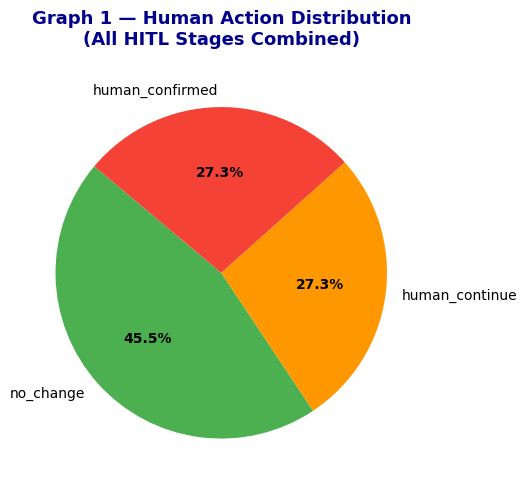

✅ Graph 1 saved → hitl_graphs/graph1_action_distribution.png

📊 Generating Graph 2 — Confidence Before vs After...


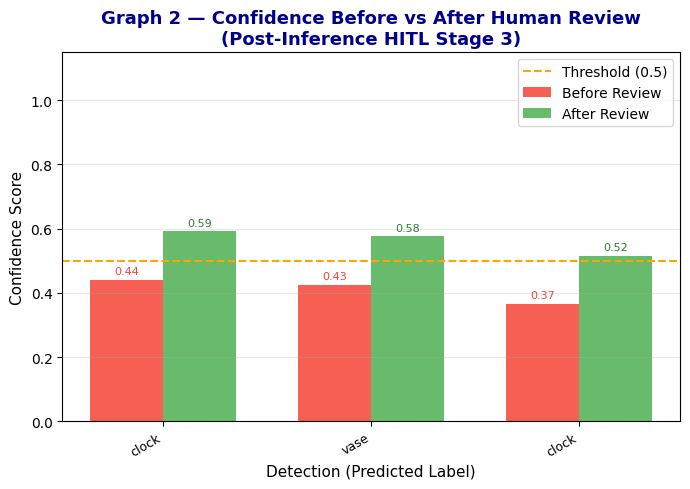

✅ Graph 2 saved → hitl_graphs/graph2_confidence_before_after.png

📊 Generating Graph 3 — Interventions per Stage...


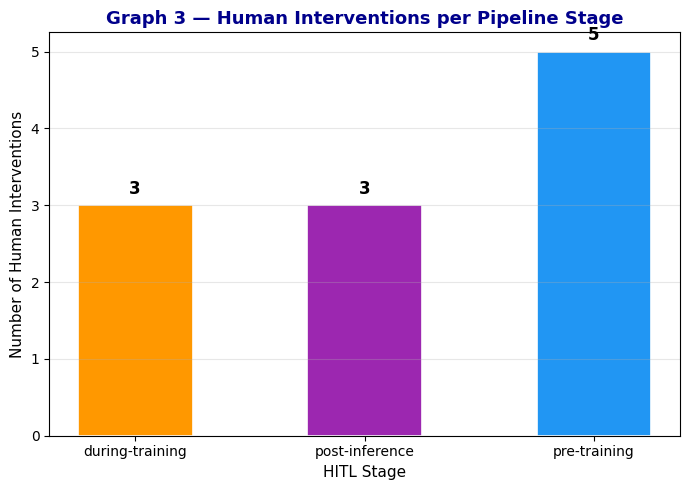

✅ Graph 3 saved → hitl_graphs/graph3_interventions_per_stage.png

📊 Generating Graph 4 — Confidence Delta...


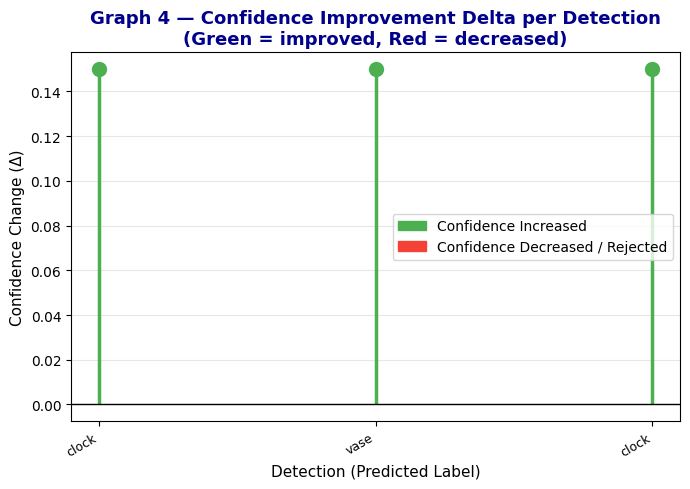

✅ Graph 4 saved → hitl_graphs/graph4_confidence_delta.png

📊 Generating Graph 5 — mAP per Epoch...
  🔍 Searching for results.csv under runs/detect/ ...
     Found: runs/detect/runs/detect/hitl_train/results.csv
  ✅ Using: runs/detect/runs/detect/hitl_train/results.csv

  📋 Columns found in results.csv:
     • 'epoch'
     • 'time'
     • 'train/box_loss'
     • 'train/cls_loss'
     • 'train/dfl_loss'
     • 'metrics/precision(B)'
     • 'metrics/recall(B)'
     • 'metrics/mAP50(B)'
     • 'metrics/mAP50-95(B)'
     • 'val/box_loss'
     • 'val/cls_loss'
     • 'val/dfl_loss'
     • 'lr/pg0'
     • 'lr/pg1'
     • 'lr/pg2'

  📊 Detected columns:
     mAP@50    column : 'metrics/mAP50(B)'
     mAP@50-95 column : 'metrics/mAP50-95(B)'
     Epoch     column : 'epoch'


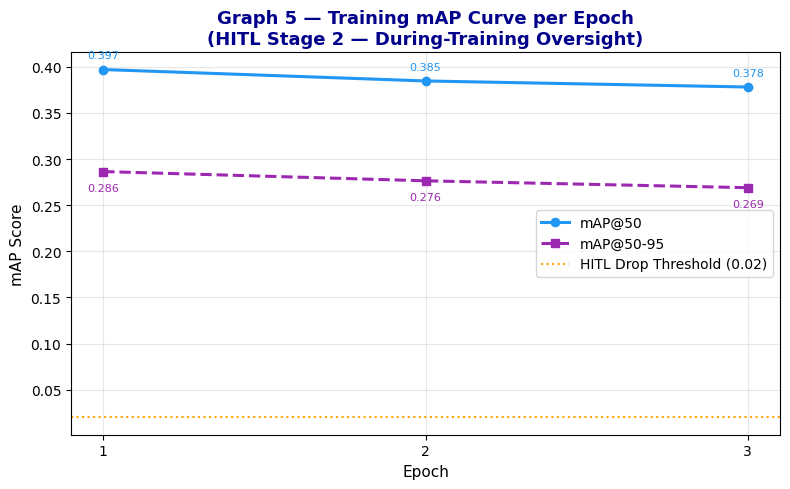

✅ Graph 5 saved → hitl_graphs/graph5_map_per_epoch.png

📊 Generating Graph 6 — Confidence Distribution...


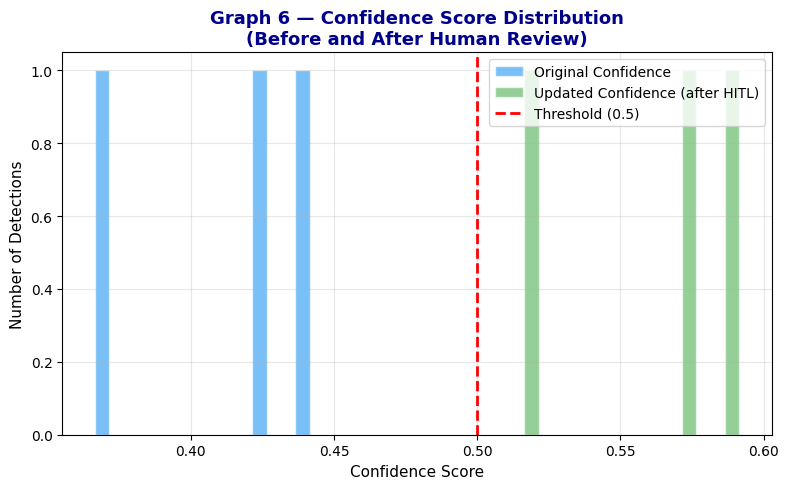

✅ Graph 6 saved → hitl_graphs/graph6_confidence_distribution.png

╔══════════════════════════════════════════════════════════╗
║   ALL GRAPHS COMPLETE                                    ║
║   Saved to: ./hitl_graphs/                              ║
╠══════════════════════════════════════════════════════════╣
║   📊  graph1_action_distribution.png                     ║
║   📊  graph2_confidence_before_after.png                 ║
║   📊  graph3_interventions_per_stage.png                 ║
║   📊  graph4_confidence_delta.png                        ║
║   📊  graph5_map_per_epoch.png                           ║
║   📊  graph6_confidence_distribution.png                 ║
╚══════════════════════════════════════════════════════════╝


In [ ]:
# ══════════════════════════════════════════════════════════════════
# CELL 14 — HITL Pipeline Output Graphs (ALL 6 GRAPHS — FINAL)
# Run AFTER Cell 12. Generates 6 analysis plots saved as PNG.
# ══════════════════════════════════════════════════════════════════

import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
from pathlib import Path

# ── Constants ─────────────────────────────────────────────────────
FEEDBACK_FILE     = "hitl_feedback.csv"
CONFIDENCE_THRESH = 0.5
MAP_DROP_THRESH   = 0.02
GRAPH_DIR         = "hitl_graphs"

os.makedirs(GRAPH_DIR, exist_ok=True)

# ── Load feedback CSV ──────────────────────────────────────────────
if not os.path.exists(FEEDBACK_FILE):
    raise FileNotFoundError(
        f"❌ '{FEEDBACK_FILE}' not found. "
        "Make sure you have run Cells 1–12 at least once before running this cell."
    )

df = pd.read_csv(FEEDBACK_FILE)
df["confidence"]         = pd.to_numeric(df["confidence"],         errors="coerce")
df["updated_confidence"] = pd.to_numeric(df["updated_confidence"], errors="coerce")

# ── Shared subsets used across multiple graphs ─────────────────────
post     = df[df["stage"] == "post-inference"].copy()
reviewed = post[post["action_taken"] != "no_review_needed"].dropna(
    subset=["confidence", "updated_confidence"]
).reset_index(drop=True)

print("╔" + "═"*58 + "╗")
print("║   HITL PIPELINE — OUTPUT GRAPHS (Cell 14)               ║")
print("║   Generating all 6 graphs...                            ║")
print("╚" + "═"*58 + "╝\n")

# ══════════════════════════════════════════════════════════════════
# GRAPH 1 — Human Actions Distribution (Pie Chart)
# ══════════════════════════════════════════════════════════════════
print("📊 Generating Graph 1 — Human Action Distribution...")

action_counts = df["action_taken"].value_counts()

fig1, ax1 = plt.subplots(figsize=(7, 5))
colors = ["#4CAF50", "#FF9800", "#F44336", "#2196F3", "#9C27B0", "#00BCD4"]
wedges, texts, autotexts = ax1.pie(
    action_counts.values,
    labels=action_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors[:len(action_counts)],
    textprops={"fontsize": 10}
)
for at in autotexts:
    at.set_fontweight("bold")
ax1.set_title(
    "Graph 1 — Human Action Distribution\n(All HITL Stages Combined)",
    fontsize=13, fontweight="bold", color="darkblue", pad=15
)
plt.tight_layout()
p1 = f"{GRAPH_DIR}/graph1_action_distribution.png"
plt.savefig(p1, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Graph 1 saved → {p1}\n")

# ══════════════════════════════════════════════════════════════════
# GRAPH 2 — Confidence Before vs After (Bar Chart, post-inference only)
# ══════════════════════════════════════════════════════════════════
print("📊 Generating Graph 2 — Confidence Before vs After...")

if not reviewed.empty:
    x      = np.arange(len(reviewed))
    width  = 0.35
    labels = reviewed["predicted_label"].astype(str)

    fig2, ax2 = plt.subplots(figsize=(max(7, len(reviewed) * 1.5), 5))
    bars_before = ax2.bar(x - width/2, reviewed["confidence"],
                          width, label="Before Review", color="#F44336", alpha=0.85)
    bars_after  = ax2.bar(x + width/2, reviewed["updated_confidence"],
                          width, label="After Review",  color="#4CAF50", alpha=0.85)

    for bar in bars_before:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.2f}", ha="center", va="bottom",
                 fontsize=8, color="#F44336")
    for bar in bars_after:
        ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f"{bar.get_height():.2f}", ha="center", va="bottom",
                 fontsize=8, color="#2e7d32")

    ax2.set_xlabel("Detection (Predicted Label)", fontsize=11)
    ax2.set_ylabel("Confidence Score", fontsize=11)
    ax2.set_title(
        "Graph 2 — Confidence Before vs After Human Review\n(Post-Inference HITL Stage 3)",
        fontsize=13, fontweight="bold", color="darkblue"
    )
    ax2.set_xticks(x)
    ax2.set_xticklabels(labels, rotation=30, ha="right", fontsize=9)
    ax2.set_ylim(0, 1.15)
    ax2.axhline(CONFIDENCE_THRESH, color="orange", linestyle="--",
                linewidth=1.5, label=f"Threshold ({CONFIDENCE_THRESH})")
    ax2.legend(fontsize=10)
    ax2.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    p2 = f"{GRAPH_DIR}/graph2_confidence_before_after.png"
    plt.savefig(p2, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Graph 2 saved → {p2}\n")
else:
    print("⚠️  Graph 2 skipped — no reviewed post-inference detections found.\n")

# ══════════════════════════════════════════════════════════════════
# GRAPH 3 — Interventions per Stage (Bar Chart)
# ══════════════════════════════════════════════════════════════════
print("📊 Generating Graph 3 — Interventions per Stage...")

stage_counts = df.groupby("stage")["action_taken"].count().reset_index()
stage_counts.columns = ["Stage", "Interventions"]

stage_colors = {
    "pre-training":    "#2196F3",
    "during-training": "#FF9800",
    "post-inference":  "#9C27B0"
}
bar_colors = [stage_colors.get(s, "#607D8B") for s in stage_counts["Stage"]]

fig3, ax3 = plt.subplots(figsize=(7, 5))
bars3 = ax3.bar(
    stage_counts["Stage"], stage_counts["Interventions"],
    color=bar_colors, edgecolor="white", linewidth=1.2, width=0.5
)
for bar in bars3:
    ax3.text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
        str(int(bar.get_height())), ha="center", va="bottom",
        fontsize=12, fontweight="bold"
    )
ax3.set_xlabel("HITL Stage", fontsize=11)
ax3.set_ylabel("Number of Human Interventions", fontsize=11)
ax3.set_title(
    "Graph 3 — Human Interventions per Pipeline Stage",
    fontsize=13, fontweight="bold", color="darkblue"
)
ax3.grid(axis="y", alpha=0.3)
plt.tight_layout()
p3 = f"{GRAPH_DIR}/graph3_interventions_per_stage.png"
plt.savefig(p3, dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Graph 3 saved → {p3}\n")

# ══════════════════════════════════════════════════════════════════
# GRAPH 4 — Confidence Improvement Delta (Lollipop Chart)
# ══════════════════════════════════════════════════════════════════
print("📊 Generating Graph 4 — Confidence Delta...")

if not reviewed.empty:
    reviewed["delta"] = reviewed["updated_confidence"] - reviewed["confidence"]
    colors_delta = ["#4CAF50" if d >= 0 else "#F44336" for d in reviewed["delta"]]

    fig4, ax4 = plt.subplots(figsize=(max(7, len(reviewed) * 1.5), 5))
    for i, (delta, col) in enumerate(zip(reviewed["delta"], colors_delta)):
        ax4.vlines(i, 0, delta, color=col, linewidth=2.5)
        ax4.plot(i, delta, "o", color=col, markersize=10, zorder=5)

    ax4.axhline(0, color="black", linewidth=1)
    ax4.set_xticks(range(len(reviewed)))
    ax4.set_xticklabels(
        reviewed["predicted_label"].astype(str),
        rotation=30, ha="right", fontsize=9
    )
    ax4.set_ylabel("Confidence Change (Δ)", fontsize=11)
    ax4.set_xlabel("Detection (Predicted Label)", fontsize=11)
    ax4.set_title(
        "Graph 4 — Confidence Improvement Delta per Detection\n"
        "(Green = improved, Red = decreased)",
        fontsize=13, fontweight="bold", color="darkblue"
    )
    ax4.grid(axis="y", alpha=0.3)
    pos_patch = mpatches.Patch(color="#4CAF50", label="Confidence Increased")
    neg_patch = mpatches.Patch(color="#F44336", label="Confidence Decreased / Rejected")
    ax4.legend(handles=[pos_patch, neg_patch], fontsize=10)
    plt.tight_layout()
    p4 = f"{GRAPH_DIR}/graph4_confidence_delta.png"
    plt.savefig(p4, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Graph 4 saved → {p4}\n")
else:
    print("⚠️  Graph 4 skipped — no reviewed detections.\n")

# ══════════════════════════════════════════════════════════════════
# GRAPH 5 — mAP per Epoch  ✅ FULLY FIXED VERSION
# Fix 1 : glob search replaces hardcoded path (handles auto-incremented folders)
# Fix 2 : pd.Series(range(...)) replaces bare range() in fillna()
# Fix 3 : dynamic column detection works across all Ultralytics versions
# ══════════════════════════════════════════════════════════════════
print("📊 Generating Graph 5 — mAP per Epoch...")

# ── Step 1: Dynamically find the most recent results.csv ──────────
_possible_csvs = sorted(
    glob.glob("runs/detect/**/results.csv", recursive=True)
)

print(f"  🔍 Searching for results.csv under runs/detect/ ...")
if _possible_csvs:
    for _p in _possible_csvs:
        print(f"     Found: {_p}")
    _results_csv = _possible_csvs[-1]       # always use the most recent run
    print(f"  ✅ Using: {_results_csv}")
else:
    _results_csv = None
    print("  ❌ No results.csv found anywhere under runs/detect/")

# ── Step 2: Plot if found, else render a clear placeholder ────────
if _results_csv and os.path.exists(_results_csv):
    tr = pd.read_csv(_results_csv)
    tr.rename(columns=lambda c: c.strip(), inplace=True)   # strip all whitespace

    print(f"\n  📋 Columns found in results.csv:")
    for col in tr.columns.tolist():
        print(f"     • '{col}'")

    # Identify mAP columns regardless of Ultralytics version
    map50_col   = next(
        (c for c in tr.columns if "mAP50"    in c and "95" not in c), None
    )
    map5095_col = next(
        (c for c in tr.columns if "mAP50-95" in c or "mAP50_95" in c), None
    )
    epoch_col   = next(
        (c for c in tr.columns if c.lower() == "epoch"), None
    )

    print(f"\n  📊 Detected columns:")
    print(f"     mAP@50    column : '{map50_col}'")
    print(f"     mAP@50-95 column : '{map5095_col}'")
    print(f"     Epoch     column : '{epoch_col}'")

    # Build x-axis — FIX: pd.Series instead of bare range()
    if epoch_col:
        _numeric_epoch = pd.to_numeric(tr[epoch_col], errors="coerce")
        _fallback      = pd.Series(range(1, len(tr) + 1))  # ✅ pd.Series not range()
        x_axis         = _numeric_epoch.fillna(_fallback)
    else:
        x_axis = pd.Series(range(1, len(tr) + 1))

    if map50_col or map5095_col:
        fig5, ax5 = plt.subplots(figsize=(8, 5))

        if map50_col:
            map50_values = pd.to_numeric(tr[map50_col], errors="coerce")
            ax5.plot(x_axis, map50_values,
                     marker="o", color="#2196F3", linewidth=2.2,
                     label="mAP@50", zorder=3)
            for xi, yi in zip(x_axis, map50_values):
                if pd.notna(yi):
                    ax5.annotate(f"{yi:.3f}", xy=(xi, yi),
                                 xytext=(0, 8), textcoords="offset points",
                                 ha="center", fontsize=8, color="#2196F3")

        if map5095_col:
            map5095_values = pd.to_numeric(tr[map5095_col], errors="coerce")
            ax5.plot(x_axis, map5095_values,
                     marker="s", color="#9C27B0", linewidth=2.2,
                     label="mAP@50-95", linestyle="--", zorder=3)
            for xi, yi in zip(x_axis, map5095_values):
                if pd.notna(yi):
                    ax5.annotate(f"{yi:.3f}", xy=(xi, yi),
                                 xytext=(0, -14), textcoords="offset points",
                                 ha="center", fontsize=8, color="#9C27B0")

        ax5.axhline(MAP_DROP_THRESH, color="orange", linestyle=":",
                    linewidth=1.5, label=f"HITL Drop Threshold ({MAP_DROP_THRESH})")
        ax5.set_xlabel("Epoch", fontsize=11)
        ax5.set_ylabel("mAP Score", fontsize=11)
        ax5.set_title(
            "Graph 5 — Training mAP Curve per Epoch\n"
            "(HITL Stage 2 — During-Training Oversight)",
            fontsize=13, fontweight="bold", color="darkblue"
        )
        ax5.set_xticks(x_axis)
        ax5.legend(fontsize=10)
        ax5.grid(alpha=0.3)
        plt.tight_layout()
        p5 = f"{GRAPH_DIR}/graph5_map_per_epoch.png"
        plt.savefig(p5, dpi=150, bbox_inches="tight")
        plt.show()
        print(f"✅ Graph 5 saved → {p5}\n")

    else:
        print("⚠️  Graph 5 skipped — mAP columns not found in results.csv")
        print(f"    Available columns: {tr.columns.tolist()}\n")

else:
    # Render a visible placeholder so all 6 graphs always exist
    print("⚠️  Graph 5: results.csv not found — rendering placeholder.\n")
    fig5, ax5 = plt.subplots(figsize=(8, 5))
    ax5.text(
        0.5, 0.5,
        "Graph 5 — mAP Curve\nNot available:\n"
        "results.csv not found under runs/detect/\n\n"
        "Ensure training (Cell 8) completed\nsuccessfully before running Cell 14.",
        transform=ax5.transAxes,
        ha="center", va="center", fontsize=13, color="red",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="#fff3cd",
                  edgecolor="#ff6b00", linewidth=2)
    )
    ax5.set_title("Graph 5 — Training mAP Curve (Unavailable)",
                  fontsize=13, fontweight="bold", color="darkred")
    ax5.axis("off")
    plt.tight_layout()
    p5 = f"{GRAPH_DIR}/graph5_map_per_epoch.png"
    plt.savefig(p5, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Graph 5 placeholder saved → {p5}\n")

# ══════════════════════════════════════════════════════════════════
# GRAPH 6 — Post-Inference Confidence Distribution (Histogram)
# ══════════════════════════════════════════════════════════════════
print("📊 Generating Graph 6 — Confidence Distribution...")

if not post.empty and post["confidence"].notna().any():
    fig6, ax6 = plt.subplots(figsize=(8, 5))

    ax6.hist(post["confidence"].dropna(), bins=15, color="#2196F3", alpha=0.6,
             edgecolor="white", label="Original Confidence")

    updated = post["updated_confidence"].dropna()
    if not updated.empty:
        ax6.hist(updated, bins=15, color="#4CAF50", alpha=0.6,
                 edgecolor="white", label="Updated Confidence (after HITL)")

    ax6.axvline(CONFIDENCE_THRESH, color="red", linestyle="--", linewidth=2,
                label=f"Threshold ({CONFIDENCE_THRESH})")
    ax6.set_xlabel("Confidence Score", fontsize=11)
    ax6.set_ylabel("Number of Detections", fontsize=11)
    ax6.set_title(
        "Graph 6 — Confidence Score Distribution\n(Before and After Human Review)",
        fontsize=13, fontweight="bold", color="darkblue"
    )
    ax6.legend(fontsize=10)
    ax6.grid(alpha=0.3)
    plt.tight_layout()
    p6 = f"{GRAPH_DIR}/graph6_confidence_distribution.png"
    plt.savefig(p6, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"✅ Graph 6 saved → {p6}\n")
else:
    print("⚠️  Graph 6 skipped — no post-inference data available.\n")

# ── Final Summary ──────────────────────────────────────────────────
print("╔" + "═"*58 + "╗")
print("║   ALL GRAPHS COMPLETE                                    ║")
print(f"║   Saved to: ./{GRAPH_DIR}/                              ║")
print("╠" + "═"*58 + "╣")
for name in sorted(os.listdir(GRAPH_DIR)):
    print(f"║   📊  {name:<51}║")
print("╚" + "═"*58 + "╝")
